In [3]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [4]:
df = pd.read_csv('../data/Boston.csv', index_col='Unnamed: 0')
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
x = df.iloc[:,:-1].values
x

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]])

In [6]:
y = df.iloc[:,[-1]].values
y

array([[24. ],
       [21.6],
       [34.7],
       [33.4],
       [36.2],
       [28.7],
       [22.9],
       [27.1],
       [16.5],
       [18.9],
       [15. ],
       [18.9],
       [21.7],
       [20.4],
       [18.2],
       [19.9],
       [23.1],
       [17.5],
       [20.2],
       [18.2],
       [13.6],
       [19.6],
       [15.2],
       [14.5],
       [15.6],
       [13.9],
       [16.6],
       [14.8],
       [18.4],
       [21. ],
       [12.7],
       [14.5],
       [13.2],
       [13.1],
       [13.5],
       [18.9],
       [20. ],
       [21. ],
       [24.7],
       [30.8],
       [34.9],
       [26.6],
       [25.3],
       [24.7],
       [21.2],
       [19.3],
       [20. ],
       [16.6],
       [14.4],
       [19.4],
       [19.7],
       [20.5],
       [25. ],
       [23.4],
       [18.9],
       [35.4],
       [24.7],
       [31.6],
       [23.3],
       [19.6],
       [18.7],
       [16. ],
       [22.2],
       [25. ],
       [33. ],
       [23.5],
       [19

In [7]:
model = LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### LinearRegression

In [8]:
# 01. 기울기와 절편
model.coef_
model.intercept_
print("기울기:", model.coef_)
print("절편:", model.intercept_)

기울기: [[-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
  -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
   3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
  -5.24758378e-01]]
절편: [36.45948839]


In [9]:
# 02. 0번째와 6번쨰 행의 데이터로 주택 중위 가격을 예측
model.predict(x[[0,6]])

array([[30.00384338],
       [23.00180827]])

In [10]:
predm = model.predict(x)

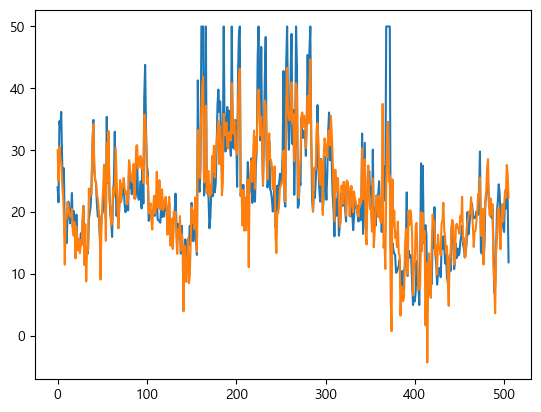

In [11]:
# 03. 실제 medv와 예측 medv 라인차트
plt.plot(y)
plt.plot(predm)
plt.show()

In [12]:
# 04. 결정계수 R² 값 구하기
model.score(x, y)

0.7406426641094094

### SGD

In [13]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [14]:
sgd = SGDRegressor(verbose=100, n_iter_no_change=100, max_iter=2000)
sgd.fit(x,y)

-- Epoch 1
Norm: 3043937789739.80, NNZs: 13, Bias: 17459472616.708542, T: 506, Avg. loss: 180143119844225387967692144640.000000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1236678571120.09, NNZs: 13, Bias: 3593594778.768134, T: 1012, Avg. loss: 80122865875473636720140877824.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1119080719214.66, NNZs: 13, Bias: 1886867409.768620, T: 1518, Avg. loss: 62186914734163828375235330048.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1385440472682.74, NNZs: 13, Bias: 375264286.587771, T: 2024, Avg. loss: 50865636443987093942312108032.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1550782617953.62, NNZs: 13, Bias: 3886901867.809212, T: 2530, Avg. loss: 44238624217319518100107821056.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1637340078657.37, NNZs: 13, Bias: -1399174882.315617, T: 3036, Avg. loss: 42223019520351413155382951936.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1538022755

c:\Python310\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,2000
,tol,0.001
,shuffle,True
,verbose,100
,epsilon,0.1
,random_state,None


In [15]:
# 01. 기울기와 절편
sgd.coef_
sgd.intercept_
print("기울기:", sgd.coef_)
print("절편:", sgd.intercept_)

기울기: [ 2.74004512e+09  7.10807118e+10  6.78634038e+10  7.88953877e+10
  3.22250190e+10  8.71109126e+10 -6.23561308e+10  8.21223459e+10
 -1.44980216e+11 -3.93116254e+10 -1.18368173e+11  1.67895629e+11
  7.67979374e+09]
절편: [2.54236658e+10]


In [16]:
# 02. 0번째와 6번쨰 행의 데이터로 주택 중위 가격을 예측
sgd.predict(x[[0,6]])

array([5.14057766e+13, 5.00575372e+13])

In [17]:
preds = sgd.predict(x)

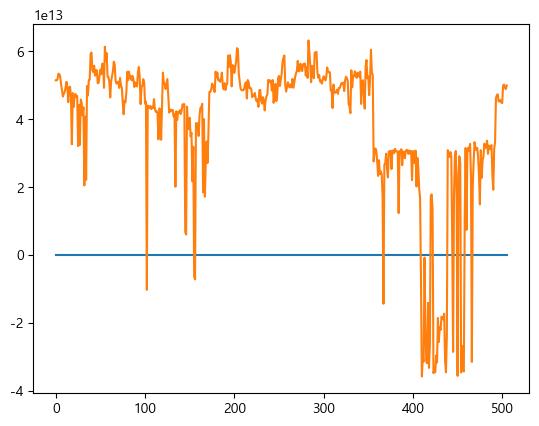

In [18]:
# 03. 실제 medv와 예측 medv 라인차트
plt.plot(y)
plt.plot(preds)
plt.show()

In [19]:
# 04. 결정계수 R² 값 구하기
r2_score(y, preds)

-2.2962471391275114e+25

### 정규화(표준화)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)
x_scaled

array([[-0.41978194,  0.28482986, -1.2879095 , ..., -1.45900038,
         0.44105193, -1.0755623 ],
       [-0.41733926, -0.48772236, -0.59338101, ..., -0.30309415,
         0.44105193, -0.49243937],
       [-0.41734159, -0.48772236, -0.59338101, ..., -0.30309415,
         0.39642699, -1.2087274 ],
       ...,
       [-0.41344658, -0.48772236,  0.11573841, ...,  1.17646583,
         0.44105193, -0.98304761],
       [-0.40776407, -0.48772236,  0.11573841, ...,  1.17646583,
         0.4032249 , -0.86530163],
       [-0.41500016, -0.48772236,  0.11573841, ...,  1.17646583,
         0.44105193, -0.66905833]])

In [22]:
rows_scaled = scalar.transform(x[[0,6]])
rows_scaled

array([[-0.41978194,  0.28482986, -1.2879095 , -0.27259857, -0.14421743,
         0.41367189, -0.12001342,  0.1402136 , -0.98284286, -0.66660821,
        -1.45900038,  0.44105193, -1.0755623 ],
       [-0.41024282,  0.04877224, -0.47665354, -0.27259857, -0.26515405,
        -0.38841095, -0.07022862,  0.83924392, -0.52300145, -0.57751897,
        -1.50523663,  0.42679827, -0.03126762]])

In [23]:
sgd2 = SGDRegressor(verbose=100, n_iter_no_change=100, max_iter=2000)
sgd2.fit(x_scaled,y)

-- Epoch 1
Norm: 4.53, NNZs: 13, Bias: 17.188960, T: 506, Avg. loss: 87.412187
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 5.23, NNZs: 13, Bias: 20.536475, T: 1012, Avg. loss: 18.784475
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 5.53, NNZs: 13, Bias: 21.675019, T: 1518, Avg. loss: 12.991736
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 5.56, NNZs: 13, Bias: 22.140834, T: 2024, Avg. loss: 11.989799
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 5.78, NNZs: 13, Bias: 22.342743, T: 2530, Avg. loss: 11.768152
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 5.93, NNZs: 13, Bias: 22.466774, T: 3036, Avg. loss: 11.566344
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 6.01, NNZs: 13, Bias: 22.498104, T: 3542, Avg. loss: 11.517508
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 6.08, NNZs: 13, Bias: 22.491111, T: 4048, Avg. loss: 11.474018
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 6.11, NNZs: 13, Bias: 22.516981, T: 4554, Avg. loss: 11.421470
T

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,2000
,tol,0.001
,shuffle,True
,verbose,100
,epsilon,0.1
,random_state,None


In [24]:
sgd.coef_
sgd.intercept_
print("기울기:", sgd2.coef_)
print("절편:", sgd2.intercept_)

기울기: [-0.92939646  1.08141037  0.13319159  0.6635252  -2.05995266  2.65777944
  0.01655526 -3.10388882  2.6517386  -2.07203522 -2.06050979  0.85122784
 -3.73179588]
절편: [22.52571555]


In [25]:
sgd2.predict(x_scaled[[0,6]])

array([30.00129065, 23.01450428])

In [26]:
preds2 = sgd2.predict(x_scaled)

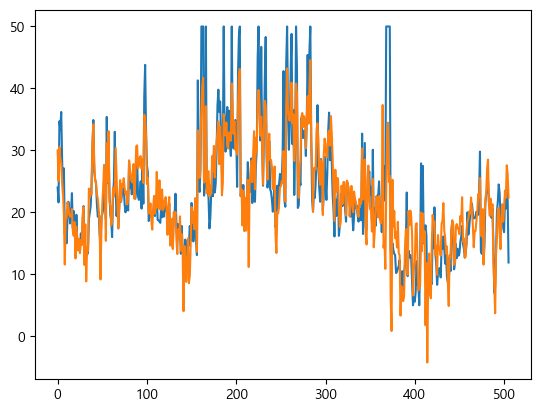

In [27]:
plt.plot(y)
plt.plot(preds2)
# plt.plot(predm)
plt.show()

In [28]:
r2_score(y, preds2)

0.7406308219962936